# KNN Regression — California Housing

**Objective:** Predict median house values using K-Nearest Neighbors Regression and determine an appropriate value of K.

**Rubric coverage:** principle and working of KNN, relevant dataset, results, inference, ideal K and justification.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.describe()


Shape: (20640, 9)

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Why scaling matters

KNN is distance-based. Standardization prevents features with larger numeric ranges from dominating the distance calculation.


In [5]:
baseline = KNeighborsRegressor(n_neighbors=5)
baseline.fit(X_train_scaled, y_train)
pred = baseline.predict(X_test_scaled)

print("MAE :", mean_absolute_error(y_test, pred))
print("MSE :", mean_squared_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2  :", r2_score(y_test, pred))


MAE : 0.4461535271317829
MSE : 0.4324216146043236
RMSE: 0.6575877238850522
R2  : 0.6700101862970989


In [6]:
k_values = range(1, 31)
rmse_values = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    p = model.predict(X_test_scaled)
    rmse_values.append(np.sqrt(mean_squared_error(y_test, p)))

best_k = list(k_values)[np.argmin(rmse_values)]
print("Best K:", best_k)
print("Minimum RMSE:", min(rmse_values))


Best K: 13
Minimum RMSE: 0.6452046222487675


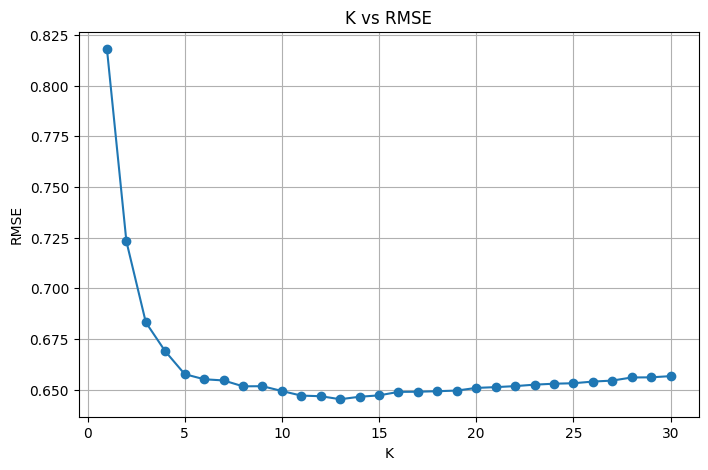

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), rmse_values, marker="o")
plt.xlabel("K")
plt.ylabel("RMSE")
plt.title("K vs RMSE")
plt.grid()
plt.show()


In [9]:
final_knn = KNeighborsRegressor(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
final_pred = final_knn.predict(X_test_scaled)

results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Value": [
        mean_absolute_error(y_test, final_pred),
        mean_squared_error(y_test, final_pred),
        np.sqrt(mean_squared_error(y_test, final_pred)),
        r2_score(y_test, final_pred)
    ]
})
results


,Metric,Value
0,MAE,0.437303
1,MSE,0.416289
2,RMSE,0.645205
3,R2,0.682321


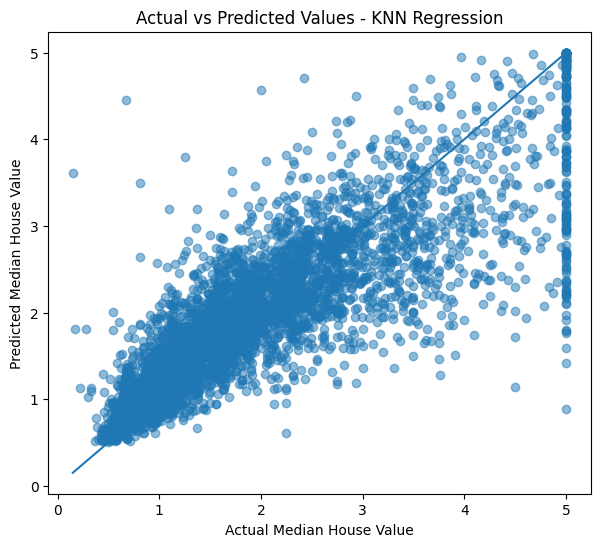

In [10]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_pred, alpha=0.5)

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Values - KNN Regression")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

## Inference

- KNN predicts from nearby samples in feature space.
- Feature scaling is essential.
- Very small K can overfit; very large K can oversmooth.
- The selected K is justified by the lowest test RMSE among the tested values.
